# GPT

## GPT 학습을 위한 데이터세트 구성

GPT 모델 또한 일반적으로 사전학습과 미세조정 두가지의 학습 단계가 존재합니다.

- **사전 학습**
    * 웹 텍스트나 책, 논문, 뉴스 등 다양한 출처의 방대한 텍스트 데이터를 활용하여 사전학습을 진행
    * 특수한 라벨이나 태그가 달려 있지 않으며, 자연어 형태(대체로 가공되지 않은(unlabeled) 텍스트 형태)로 학습
    * 욕설・중복 등 품질이 매우 낮은 텍스트를 걸러내는 등의 기본적인 전처리(cleaning) 작업만 진행

- **미세조정**
    * 적절한 대화가 유도 되도록 프폼프트와 답변을 라벨링한 대화형 학습 데이터(Instruction tuning 데이터)세트를 구성하여 하여 미세조정
    * 시스템 역할, 사용자 역할, 도우미 역할 등 **역할 토큰(role token)**과 문장 시작, 문장 끝 등의 **특수 토큰**을 추가하여 대화의 맥락, 혹은 지시문의 종류 등을 명확히 파악하도록 유도


이번 예시에서는 간단한 모델 구현과 학습 과정만을 보기 위해 사전학습과 미세조정을 나누지 않고 [AIHUB](https://www.aihub.or.kr/aihubdata/data/view.do?currMenu=115&topMenu=100&dataSetSn=86) 한국어 감성 대화 말뭉치를 부분적으로 활용하여 특수토큰이 포함된 질의,응답 데이터세트로 학습을 진행합니다.

# 한국어 감성 대화형 Mini-GPT 밑바닥부터 구현하기 (Pre-training)

## 1. 프로젝트 정체성 (What are we doing?)
이 프로젝트는 이미 학습된 모델(GPT-4, LLaMA 등)을 가져와 튜닝하는 것이 **아니라**, **GPT(Decoder-only Transformer) 모델의 구조를 코드로 직접 설계**하고, 아무것도 모르는 백지상태(Random Weights)에서 한국어 대화 데이터를 통해 언어를 가르치는 **사전 학습(Pre-training)** 과정입니다.

---

## 2. 전체 구현 파이프라인 (Workflow)

---

# **STEP 1: 데이터 엔지니어링 (Data Engineering)**
> **"AI가 읽을 수 있는 교과서 만들기"**
- **소스 데이터**: AIHub 한국어 감성 대화 말뭉치 (`.csv`)
- **텍스트 전처리**: 특수문자 제거, 불필요한 공백 및 태그 정리 (정규표현식 활용)
- **토크나이저 학습**: `SentencePiece(BPE)` 알고리즘을 사용하여 한국어의 서브워드(Subword) 단위 단어장 생성 (`vocab_size=4000`)

BPE를 한 줄로 요약하면
**“글자를 하나하나로 시작해서, 자주 붙어 다니는 글자 조합을 점점 합쳐서 단어처럼 만들어가는 방법”**이에요.

📖 예시로 직관적으로 이해하기
1. 문자 단위로 시작
안녕하세요 → [안][녕][하][세][요]

처음에는 모든 글자를 따로따로 토큰으로 둡니다.

2. 자주 붙는 쌍 찾기
- 말뭉치 전체를 보면 [안][녕]이 자주 나오고
- [하세요]도 자주 붙어 나옵니다.
3. 가장 자주 나온 쌍을 합치기
- [안][녕] → [안녕]
- [하][세] → [하세]
- [하세][요] → [하세요]
4. 반복
- 계속해서 자주 나오는 쌍을 합치다 보면,
- [안녕하세요] 같은 긴 토큰도 생기고
- 드물게 쓰이는 단어는 여전히 작은 조각으로 남습니다.

📌 직관 포인트
- 자주 쓰이는 조각은 하나의 토큰으로 승격 → 모델이 빠르게 이해 가능
- 드문 단어는 작은 조각으로 분해 → 새로운 단어도 처리 가능
- 결과적으로: 단어장 크기를 적당히 유지하면서, 희귀 단어도 커버할 수 있음

🎯 비유
- 처음엔 레고 블록을 전부 1칸짜리로 쪼개 놓고 시작합니다.
- 자주 쓰이는 블록 조합은 붙여서 큰 블록으로 만들어 놓습니다.
- 그래서 나중에 집을 지을 때(문장을 만들 때) 큰 블록은 빠르게 쓰고, 희귀한 모양은 작은 블록 여러 개로 조립하면 됩니다.


## BPE에서 본 "사전 크기 vs 문장 토큰 개수" 관계

| BPE 병합 횟수 | Vocab Size | 문장 토큰 개수 | 문장 표현 |
|---------------|------------|----------------|-----------|
| 0 (초기) | 작음 (~20) | 11개 | [안][녕][하][세][요] [안][녕][하][셨][나][요] |
| 중간 | 중간 (~4,000) | 4개 | [안녕][하세요] [안녕][하셨나요] |
| 많음 | 큼 (~30,000) | 2개 | [안녕하세요] [안녕하셨나요] |

---

## ✅ BPE 관점에서의 핵심 이해

**"BPE에서 vocab_size를 키운다는 것은 = 더 많은 병합(merge) 규칙을 학습한다는 것"**

- **사전이 작음** = 병합 규칙이 적음 = 토큰이 잘게 쪼개짐 = **문장 당 토큰 개수 많음**
- **사전이 큼** = 병합 규칙이 많음 = 토큰이 덩어리로 묶임 = **문장 당 토큰 개수 적음**

**반비례의 비밀:** 우리가 "토큰 개수를 늘리겠다"고 선택하는 게 아니라, **사전 크기를 키울수록 BPE가 더 많은 병합을 통해 토큰을 크게 만들기 때문에, 자연스럽게 문장을 표현하는 데 필요한 토큰 개수가 줄어드는 결과**가 발생하는 것입니다!


---


# **STEP 2: 데이터 파이프라인 구축 (Dataset Pipeline)**
> **"학습하기 좋은 형태로 도시락 싸기"**
- **`SPDataSet` 클래스 구현**:
    - 텍스트를 토큰 ID(숫자)로 변환
    - `[BOS]`(시작), `[EOS]`(끝) 특수 토큰 추가
    - 배치 처리를 위한 **제로 패딩(Zero Padding)** 및 마스킹
- **Teacher Forcing 라벨링**: 모델이 다음 단어를 맞추도록 **정답(Target)을 입력(Input)보다 한 칸 뒤로 미룬 형태**로 구성

# Teacher Forcing: GPT 학습 방식 이해하기

## 🎯 Teacher Forcing 이란?

**훈련 시에만** 모델에게 정답을 알려주면서 학습시키는 방법  
→ 학생(모델)이 문제를 풀 때, 선생님(훈련 데이터)이 다음 단계의 힌트를 계속 제공하는 방식

핵심 질문 답변

Q: 입력 = 힌트인가?
A: 네! 입력은 모델에게 주는 "지금까지의 문맥 힌트"입니다.

Q: 사람이 주는 건가?
A: 직접적으로는 아닙니다. 사람은 원본 데이터만 제공하고, 코드가 자동으로 (input, target) 쌍을 생성합니다.

Q: 모델이 자기가 한 걸 보는 건가?
A: 아닙니다! 이것이 핵심입니다.

학습 시: 모델은 항상 진짜 정답(ground truth)을 input으로 받음

실제 사용 시: 모델은 자기가 예측한 결과를 input으로 받음

---

## 📝 기본 개념

```
입력: [지금까지의 문장]
정답: [다음에 올 단어]  ← 한 칸 뒤로 미룬 라벨
```

---

## 🤖 GPT 학습 과정 예시

### **원본 문장**
```
"딥러닝은 재미있어"
```

### **토큰화 (BPE 기준)**
```
[딥] [러닝] [은] [재] [미] [있] [어]
```

---

## 🔄 Teacher Forcing 단계별 학습

| 단계 | 모델 입력 (X) | 예측 대상 (Y) | 학습 포인트 |
|------|---------------|---------------|-------------|
| 1 | `[START]` | `[딥]` | 시작 다음에는 '딥'이 옴 |
| 2 | `[START] [딥]` | `[러닝]` | '딥' 다음에는 '러닝'이 옴 |
| 3 | `[START] [딥] [러닝]` | `[은]` | '딥러닝' 다음에는 '은'이 옴 |
| 4 | `[START] [딥] [러닝] [은]` | `[재]` | '딥러닝은' 다음에는 '재'가 옴 |
| 5 | `[START] [딥] [러닝] [은] [재]` | `[미]` | '재' 다음에는 '미'가 옴 |
| 6 | `[START] [딥] [러닝] [은] [재] [미]` | `[있]` | '재미' 다음에는 '있'이 옴 |
| 7 | `[START] [딥] [러닝] [은] [재] [미] [있]` | `[어]` | '재미있' 다음에는 '어'가 옴 |

---

## 🎓 학습 시나리오

### **첫 번째 스텝**
```python
입력:  [START]
예측:  [???]  # 모델이 예측 시도
정답:  [딥]   # 실제 정답
```
→ 모델 학습: "시작 토큰 다음에는 '딥'이 나와야 하는구나!"

### **두 번째 스텝**
```python
입력:  [START] [딥]
예측:  [???]  # 모델이 예측 시도
정답:  [러닝] # 실제 정답
```
→ 모델 학습: "'딥' 다음에는 '러닝'이 나와야 하는구나!"

---

## ⚖️ 학습 vs 추론 차이

### **학습 시 (Teacher Forcing)**
```
입력: [START] [딥] [러닝] [은]  ← 진짜 정답으로 구성
정답: [재]                     ← 선생님이 답 알려줌
```

### **실제 사용 시 (No Teacher Forcing)**
```
입력: [START] [딥] [러닝] [은]  ← 모델의 이전 출력으로 구성
출력: [재]                     ← 모델이 스스로 예측
↓
다음 입력: [START] [딥] [러닝] [은] [재]  ← 예측 결과로 이어감
```

---

## 💡 장점

- **안정적인 학습**: 예측 실패가 다음 입력으로 전파되지 않음
- **빠른 수렴**: 정답을 바로 알려주므로 학습 효율 향상
- **문법 패턴 학습**: 자연스러운 언어 흐름을 효과적으로 습득

---

## ❗ 주의사항

- **훈련 시에만 사용**: 실제 추론시에는 사용 불가
- **Exposure Bias**: 훈련(정답 보기)과 추론(스스로 예측) 환경 차이 발생
- **Curriculum Learning**: 점차 정답을 덜 알려주는 방식으로 개선 가능

---

## ✅ 핵심 정리

> **"Teacher Forcing은 GPT가 언어 패턴을 배우는 가장 효율적인 방법으로,  
> 선생님이 다음 단어를 미리 알려주면서 문장의 흐름을 가르치는 것과 같다"**

이렇게 수천만 문장을 반복 학습하면, GPT는 단어 간 관계와 문법 패턴을 스스로 깨닫고  
어떤 주제든 자연스러운 글을 생성할 수 있게 됩니다!

---

### **STEP 3: 모델 아키텍처 설계 (Model Architecture)**
> **"GPT의 뇌 설계 및 조립"**
- **입력층**: `Token Embedding` + `Positional Encoding` (순서 정보 주입)
- **`MTBlock` (핵심 연산 장치)**:
    - **Masked Multi-Head Attention**: **Causal Mask**를 적용하여 미래의 정답을 미리 보지 못하도록(Cheating 방지) 차단
    - **Feed Forward Network**: 정보의 확장 및 압축, 비선형성 학습
- **적층(Stacking)**: `MTBlock`을 `num_layers`만큼 쌓아 깊이 있는 문맥 이해 능력 부여

---

# **STEP 4: 사전 학습 수행 (Pre-training Loop)**
> **"백지상태의 뇌에 한국어와 대화 패턴 주입"**
- **학습 목표**: 주어진 단어들을 보고 **다음에 올 단어 예측하기 (Next Token Prediction)**
- **최적화**: `CrossEntropyLoss` (손실 계산) + `AdamW` (가중치 업데이트)
- **검증**: Train Loss와 Validation Loss를 비교하여 과적합(Overfitting) 감시

---

# **STEP 5: 추론 및 생성 (Inference & Generation)**
> **"실전 대화 테스트"**
- **텍스트 생성 (`generate`)**: 프롬프트(질문)를 넣으면 자기회귀(Autoregressive) 방식으로 한 글자씩 답변 생성
- **디코딩**: 생성된 토큰 ID 리스트를 다시 사람이 읽을 수 있는 텍스트로 변환

In [ ]:
# ----------------------------------------------------------------------------------------------
# 1. 파일 업로드 단계
# ----------------------------------------------------------------------------------------------
# 구글 코랩(Colab) 환경에서 제공하는 파일 업로드 기능을 가져옵니다.
from google.colab import files

# 파일을 업로드하는 창을 띄웁니다.
# 실행하면 '파일 선택' 버튼이 나오고, 여기서 'train.csv' 같은 데이터 파일을 선택하면 코랩 서버로 전송됩니다.
# uploaded 변수에는 업로드된 파일의 정보가 담깁니다.
uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
# ----------------------------------------------------------------------------------------------
# 2. 라이브러리 임포트 및 데이터 로딩
# ----------------------------------------------------------------------------------------------
# 딥러닝 프레임워크인 PyTorch를 가져옵니다. (나중에 모델 만들 때 씀)
import torch
# 데이터셋을 다루기 위한 도구들을 가져옵니다. (데이터 묶음 관리, 배치 단위 로딩, 데이터 쪼개기 등)
from torch.utils.data import Dataset, DataLoader, random_split
# 구글에서 만든 텍스트 토크나이저(텍스트를 조각내는 도구) 라이브러리입니다. BPE 알고리즘을 씁니다.
import sentencepiece as spm
# 표(Table) 형태의 데이터를 다루기 위한 판다스 라이브러리입니다. 엑셀 데이터를 다룰 때 필수입니다.
import pandas as pd
# 수치 계산을 위한 넘파이 라이브러리입니다. 행렬 연산 등에 쓰입니다.
import numpy as np

# 현재 경로(./)에 있는 'train.csv' 파일을 읽어서 데이터프레임(df) 형태로 저장합니다.
# 이 파일에는 AI에게 가르칠 질문과 답변 데이터가 들어있습니다.
df = pd.read_csv(f'./train.csv')

# 데이터가 잘 읽혔는지 확인하기 위해 'HS01'(질문/사람말)과 'SS01'(답변/시스템말) 컬럼만 뽑아서 보여줍니다.
# 이렇게 하면 데이터의 앞부분 5줄 정도가 출력되어 눈으로 확인할 수 있습니다.
df[['HS01','SS01']]

,HS01,SS01
0,일은 왜 해도 해도 끝이 없을까? 화가 난다.,많이 힘드시겠어요. 주위에 의논할 상대가 있나요?
1,이번 달에 또 급여가 깎였어! 물가는 오르는데 월급만 자꾸 깎이니까 너무 화가 나.,급여가 줄어 속상하시겠어요. 월급이 줄어든 것을 어떻게 보완하실 건가요?
2,회사에 신입이 들어왔는데 말투가 거슬려. 그런 애를 매일 봐야 한다고 생각하니까 스...,회사 동료 때문에 스트레스를 많이 받는 것 같아요. 문제 해결을 위해 어떤 노력을 ...
3,직장에서 막내라는 이유로 나에게만 온갖 심부름을 시켜. 일도 많은 데 정말 분하고 ...,관련 없는 심부름을 모두 하게 되어서 노여우시군요. 어떤 것이 상황을 나아질 수 있...
4,얼마 전 입사한 신입사원이 나를 무시하는 것 같아서 너무 화가 나.,무시하는 것 같은 태도에 화가 나셨군요. 상대방의 어떤 행동이 그런 감정을 유발하는...
...,...,...
51623,나이가 먹고 이제 돈도 못 벌어 오니까 어떻게 살아가야 할지 막막해. 능력도 없고.,경제적인 문제 때문에 막막하시군요. 마음이 편치 않으시겠어요.
51624,몸이 많이 약해졌나 봐. 이제 전과 같이 일하지 못할 것 같아 너무 짜증 나.,건강에 대한 어려움 때문에 기분이 좋지 않으시군요. 속상하시겠어요.
51625,이제 어떻게 해야 할지 모르겠어. 남편도 그렇고 노후 준비도 안 되어서 미래가 걱정돼.,노후 준비에 대한 어려움 때문에 걱정이 많으시겠어요.
51626,몇십 년을 함께 살았던 남편과 이혼했어. 그동안의 세월에 배신감을 느끼고 너무 화가 나.,가족과의 문제 때문에 속상하시겠어요.


### Autoregressive 학습을 위한 데이터세트

GPT는 Transformer의 디코더 구조를 활용한 모델이므로 기본적으로 자기회귀(Autoregressive) 방식으로 왼쪽에서 오른쪽 방향으로 순차적 토큰을 생성합니다.  
따라서 학습을 위한 입력 데이터는 **(Causal) 마스크**를 통해 미래 토큰을 가려주어야 하며, 입력-라벨 구조는 단순히 입력 토큰을 **왼쪽으로 한칸씩 쉬프트** 한 토큰으로 구성이됩니다.

    원문: [오늘, 수업은, GPT, 텍스트, 생성, 수업, 이다]

    입력: [오늘, 수업은, GPT, 텍스트, 생성, 수업]

    라벨: [수업은, GPT, 텍스트, 생성, 수업, 이다]


In [ ]:
# ==============================================================================================
# [전체 흐름 요약: GPT라는 '요리'를 하기 위한 '재료 손질' 단계]
#
# 지금 하고 있는 작업은 AI(GPT)를 학습시키기 위해 데이터를 준비하는 "전처리(Preprocessing)" 과정입니다.
#
# 1. 재료 구매 (File Upload):
#    - 학습에 사용할 데이터 파일(csv)을 컴퓨터(Colab)로 가져옵니다.
#
# 2. 재료 확인 (Data Loading):
#    - 가져온 데이터가 어떻게 생겼는지 판다스(Pandas)라는 도구로 엑셀 표처럼 펼쳐서 확인합니다.
#
# 3. 재료 세척 및 다듬기 (Text Cleaning):
#    - AI가 학습하기 좋게 텍스트를 깨끗이 닦습니다.
#    - 특수문자, 쓸데없는 공백, 이상한 기호 등을 정규표현식(Regex)이라는 칼을 써서 잘라냅니다.
#    - 깨끗해진 텍스트만 따로 모아 'train.txt'라는 그릇에 담습니다.
#
# 4. 조리 도구 세팅 (Tokenizer Training):
#    - 컴퓨터는 한글이나 영어를 이해하지 못하고 숫자만 이해합니다.
#    - 그래서 글자를 숫자로 바꿔주는 '변환기(Tokenizer)'를 만들어야 합니다.
#    - 여기서는 구글의 'SentencePiece'라는 도구를 사용해 우리 데이터에 딱 맞는 변환기를 학습시킵니다.
#    - 이 변환기는 문장의 시작(BOS), 끝(EOS), 모르는 단어(UNK), 빈칸(PAD) 등을 숫자로 매핑하는 규칙을 배웁니다.
# ==============================================================================================

# ----------------------------------------------------------------------------------------------
# 3. 텍스트 정제 (Text Cleaning) - 재료 다듬기
# ----------------------------------------------------------------------------------------------
# [BPE 설명]
# BPE(Byte Pair Encoding)는 텍스트를 토큰(단어 조각)으로 쪼개는 방법 중 하나입니다.
# 자주 나오는 글자 조합은 하나로 묶고, 안 나오는 건 낱개로 쪼개서 효율적으로 단어 사전을 만듭니다.
# 이 BPE를 학습시키기 위해서는 먼저 깨끗한 텍스트 파일이 필요합니다.

import os, re  # os: 파일/폴더 관리용, re: 정규표현식(문자열 처리)용 라이브러리

# 'train.txt'라는 파일을 쓰기 모드('w')로 엽니다. 인코딩은 한글이 깨지지 않게 'utf-8'로 설정합니다.
# 이 파일에 정제된 텍스트들을 한 줄씩 꾹꾹 눌러 담을 겁니다.
with open('train.txt', 'w', encoding='utf-8') as f:
  # df['HS01']은 데이터프레임에서 질문(사람의 말) 컬럼입니다.
  # 이 컬럼에 있는 모든 문장을 하나씩 꺼내서 text 변수에 담고 반복문을 돌립니다.
  for text in df['HS01']:
        # 혹시 숫자가 들어있거나 다른 타입일 수 있으니 안전하게 문자열(string)로 변환합니다.
        text = str(text)

        # [정규표현식을 이용한 청소 작업]
        # 1. 특수문자 제거:
        #    [^\w\s] -> 문자(\w:한글,영어,숫자)나 공백(\s)이 '아닌(^)' 것들을 찾습니다.
        #    찾아서 ''(빈 문자열)로 바꿉니다. 즉, 삭제합니다. (이모티콘, #, @ 같은 거 제거)
        text = re.sub(r'[^\w\s]', '', text)     # 특수문자 제거

        # 2. 줄바꿈/탭 제거:
        #    [\n\t] -> 엔터키(\n)나 탭키(\t)를 찾아서 ' '(공백)으로 바꿉니다.
        #    문장이 한 줄로 쫙 펴지게 만듭니다.
        text = re.sub(r'[\n\t]', ' ', text)     # 줄바꿈, 탭 제거

        # 3. 연속된 공백 제거:
        #    \s+ -> 공백이 하나 이상(+) 연속으로 있는 걸 찾습니다. (예: "안녕    하세요")
        #    이걸 ' '(공백 하나)로 바꿉니다. (예: "안녕 하세요")
        text = re.sub(r'\s+', ' ', text)        # 연속된 공백 제거

        # 4. 물음표 정규화:
        #    \?{2,} -> 물음표가 2개 이상 연속된 것(??, ????)을 찾습니다.
        #    이걸 '?' 하나로 바꿉니다. (너무 과한 감정 표현 자제시키기)
        text = re.sub(r'\?{2,}', '?', text)     # ?? → ?

        # 5. 양쪽 공백 제거:
        #    문장의 맨 앞과 맨 뒤에 있는 의미 없는 공백을 잘라냅니다.
        text= text.strip()                      # 문장 양끝 공백 제거

        # 정제된 텍스트를 파일에 씁니다.
        try:
            # 텍스트 끝에 줄바꿈(\n)을 붙여서 파일에 기록합니다.
            # 이렇게 해야 나중에 토크나이저가 문장 단위로 인식할 수 있습니다.
            f.write(text+'\n')
        except:
            # 쓰기 과정에서 에러가 나면(인코딩 문제 등) 멈추지 말고 그냥 무시(pass)하고 넘어갑니다.
                pass

# ----------------------------------------------------------------------------------------------
# 4. 토크나이저(Tokenizer) 학습 - 조리 도구 만들기
# ----------------------------------------------------------------------------------------------
# 토크나이저 모델을 저장할 폴더('./bpe')를 만듭니다.
# exist_ok=True는 이미 폴더가 있으면 에러 내지 말고 그냥 쓰라는 뜻입니다.
os.makedirs('./bpe', exist_ok=True)

# [학습 - 실제 사용할 모델]
# GPT 모델 학습에 필수적인 '특수 토큰(Special Token)'들을 정의합니다.
spm.SentencePieceTrainer.train(input='train.txt',               # 텍스트 뭉치 파일
                            model_prefix='./bpe/spm_krsent',    # 출력 모델 파일 이름
                            vocab_size=4000,                    # 토큰 개수: 4000개

                            # [중요] 특수 토큰 ID 설정 (GPT 학습의 핵심)
                            # 컴퓨터는 문장의 시작과 끝을 모르기 때문에 명시적으로 알려줘야 합니다.

                            bos_id=1,   # BOS (Beginning Of Sentence): "문장 시작한다!"를 알리는 토큰의 ID를 1번으로 지정
                            eos_id=2,   # EOS (End Of Sentence): "문장 끝났다!"를 알리는 토큰의 ID를 2번으로 지정
                            unk_id=3,   # UNK (Unknown): "사전에 없는 모르는 단어다!"를 알리는 토큰의 ID를 3번으로 지정
                            pad_id=0    # PAD (Padding): "여긴 빈칸이다!" (길이 맞추기용) 토큰의 ID를 0번으로 지정
                            )

# 이 코드가 다 실행되면 './bpe' 폴더 안에 'spm_krsent.model'과 'spm_krsent.vocab' 파일이 생성됩니다.
# 이제 이 모델을 로드해서 한글 문장을 넣으면 숫자 리스트로 변환해주는 준비가 끝난 것입니다.

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 학습용 '도시락' 세트 만들기]
#
# 이 클래스(SPDataSet)는 원본 데이터(CSV)를 꺼내서 AI가 먹을 수 있는 형태(Tensor)로 가공하여
# 도시락 하나(Sample)를 포장하는 역할을 합니다.
#
# 1. 준비 단계 (__init__):
#    - 재료(CSV 파일)를 읽어오고, 조리 도구(토크나이저)를 챙깁니다.
#    - 도시락통 크기(max_len)를 정합니다.
#
# 2. 재료 손질 (zero_pad):
#    - 음식이 너무 길면 도시락통 크기에 맞춰 자르고,
#    - 음식이 너무 적으면 빈 공간이 없도록 0(padding)으로 채워 넣습니다.
#
# 3. 도시락 싸기 (__getitem__):
#    - 질문과 답변을 꺼내 숫자로 변환(Encoding)합니다.
#    - [질문] + [BOS] + [답변] + [EOS] 순서로 하나의 긴 문장으로 합칩니다.
#    - 여기서 가장 중요한 **'정답지 만들기(Labeling)'**를 수행합니다.
#      입력: "안 녕 하 세 요"
#      정답: "녕 하 세 요 [끝]"
#      (AI는 '안'을 보고 '녕'을 맞추고, '녕'을 보고 '하'를 맞춰야 하기 때문에 한 칸씩 밀어서 정답을 만듭니다)
#
# 4. 배달 준비 (DataLoader):
#    - 완성된 도시락들을 모아서 배달(학습 루프)해주는 트럭입니다.
# ==============================================================================================

# PyTorch의 Dataset 클래스를 상속받아 나만의 데이터셋 클래스를 만듭니다.
class SPDataSet(Dataset):

    # 1. 초기화 함수: 데이터셋을 처음 만들 때 딱 한 번 실행됩니다.
    def __init__(self, sp, max_len):
        self.max_len = max_len  # 문장의 최대 길이 (예: 60). 이보다 길면 자르고 짧으면 0으로 채움.

        # CSV 파일을 읽어서 질문(HS01)과 답변(SS01) 컬럼만 가져옵니다.
        # self.df에는 모든 대화 데이터가 표 형태로 저장됩니다.
        self.df = pd.read_csv(f'./train.csv')[['HS01','SS01']]

        self.sp = sp  # 앞서 학습시킨 토크나이저(SentencePiece)를 저장해둡니다.

    # 2. 패딩 함수: 문장 길이를 일정하게 맞춰주는 도우미 함수입니다.
    def zero_pad(self, tok):
        # 만약 토큰 리스트가 최대 길이보다 길거나 같다면?
        if len(tok) >= self.max_len:
            return tok[:self.max_len]  # 최대 길이까지만 싹둑 자릅니다.
        else:
            # 만약 토큰 리스트가 최대 길이보다 짧다면?
            # 1. 일단 0으로 가득 찬 최대 길이짜리 빈 그릇을 만듭니다.
            padding = np.zeros(self.max_len)
            # 2. 그릇의 앞부분부터 실제 토큰들을 채워 넣습니다. 나머지는 0으로 남습니다.
            padding[:len(tok)] = tok
            return padding

    # 3. 길이 반환 함수: 데이터가 총 몇 개인지 PyTorch에게 알려줍니다.
    def __len__(self):
        return (len(self.df))  # 전체 데이터 행의 개수를 반환

    # 4. 아이템 추출 함수: 인덱스(i)를 주면 i번째 데이터를 가공해서 반환합니다.
    def __getitem__(self, i):
        # i번째 행(질문-답변 쌍)을 데이터프레임에서 추출
        sentence_pair = self.df.iloc[i]

        # 질문과 답변을 각각 토큰 ID로 변환
        question_tokens = self.sp.encode_as_ids(sentence_pair['HS01'])  # 질문: [토큰1, 토큰2, ...]
        answer_tokens = self.sp.encode_as_ids(sentence_pair['SS01'])    # 답변: [토큰1, 토큰2, ...]

        # [문장 구성 전략]
        # 질문 → BOS(문장시작) → 답변 → EOS(문장끝) 순으로 결합
        # 예: "뭐해?" + [BOS] + "공부중" + [EOS]
        combined_tokens = question_tokens + [self.sp.bos_id()] + answer_tokens + [self.sp.eos_id()]

        # 최대 길이(max_len)에 맞게 패딩(0으로 채움) 또는 자르기
        padded_input = self.zero_pad(combined_tokens)

        # [Teacher Forcing을 위한 정답 라벨 생성]
        # GPT는 "다음 토큰 예측" 모델이므로, 입력보다 한 타임스텝 앞선 것을 정답으로 설정
        #
        # 입력: [A, B, C, D, E, 패딩...]
        # 정답: [B, C, D, E, 패딩...]
        #
        # 이렇게 해야 모델이:
        # - A를 보고 B를 예측하고
        # - A,B를 보고 C를 예측하고
        # - A,B,C를 보고 D를 예측하는 방식으로 학습

        # 1. 정답을 저장할 그릇 생성 (모두 0으로 초기화)
        target_labels = np.zeros(self.max_len)

        # 2. "입력 시퀀스에서 첫 번째 토큰을 빼고, 그 나머지를 정답 시퀀스의 앞쪽에 채워 넣는다.
        #    이렇게 하면 입력보다 한 칸 앞선 정답 시퀀스가 만들어져서, 모델이 '다음 토큰'을 맞추도록 학습할 수 있다."
        '''
        # 원본 배열
        padded_input = [START, 나는, 학교에, 간다, PAD, PAD]

        # BEFORE: target_labels 초기 상태
        target_labels = [-100, -100, -100, -100, -100, -100]

        # 실행: target_labels[:-1] = padded_input[1:]
        # 뜻: "target_labels의 마지막 칸 빼고 전부 = padded_input의 첫칸 빼고 전부"

        # AFTER: 결과
        padded_input   = [START, 나는, 학교에, 간다, PAD,    PAD]
        target_labels  = [나는,  학교에, 간다, PAD,   PAD,   -100]
        #                ↑      ↑      ↑     ↑     ↑      ↑
        #                [0]    [1]    [2]   [3]   [4]    [5]
        '''
        target_labels[:-1] = padded_input[1:]

        # [어텐션 마스크 생성]
        # 패딩 위치(값이 0인 곳)를 찾아 True로 표시
        # 이후 모델이 이 위치는 무시하도록 함
        padding_mask = torch.eq(torch.Tensor(padded_input), 0)

        # [반환 데이터]
        # 입력 시퀀스, 정답 라벨, 패딩 마스크를 텐서로 변환하여 반환
        return (
            torch.Tensor(padded_input),      # 모델 입력용 (질문 + BOS + 답변 + EOS + 패딩)
            torch.Tensor(target_labels),     # 학습용 정답 (한 타임스텝 앞선 시퀀스)
            padding_mask                     # 패딩 위치 표시 (True=패딩, False=실제토큰)
        )

# ----------------------------------------------------------------------------------------------
# 실제 실행 및 테스트 부분
# ----------------------------------------------------------------------------------------------

# 1. 토크나이저 로드
# 저장해뒀던 모델 파일을 읽어와서 프로세서를 만듭니다.
sp = spm.SentencePieceProcessor(model_file=f'./bpe/spm_krsent.model')

# 2. 데이터셋 객체 생성
# max_len을 60으로 설정했습니다. 모든 문장은 60길이의 숫자 배열이 됩니다.
dataset = SPDataSet(sp, 60)

# 3. 데이터로더 생성
# dataset: 위에서 만든 데이터셋
# batch_size=1: 한 번에 1개씩 데이터를 꺼냅니다.
# shuffle=True: 데이터를 뒤죽박죽 섞어서 꺼냅니다 (학습 효율을 위해).
dataloader = DataLoader(dataset, batch_size=1, shuffle=True)

# 4. 데이터 확인 루프
# 데이터로더에서 딱 한 번만 데이터를 꺼내서 눈으로 확인해봅니다.
for inp, tar, mask in dataloader:
    # 입력 데이터 (정수형으로 변환해서 출력)
    print("=== Input (입력) ===")
    print(inp.long())
    # 예: [10, 20, 1, 30, 40, 2, 0, 0...] -> 질문, 구분자, 답변, 끝, 패딩

    # 정답 데이터 (정수형으로 변환해서 출력)
    print("\n=== Target (정답: 한 칸 밀림) ===")
    print(tar.long())
    # 예: [20, 1, 30, 40, 2, 0, 0, 0...] -> 10 다음은 20, 20 다음은 1...

    # 마스크 데이터
    print("\n=== Mask (패딩 위치) ===")
    print(mask)
    # 예: [False, False, ..., True, True] -> 0인 부분만 True

    break # 하나만 보고 바로 반복문 종료

tensor([[  29,  126,  466,    8, 1432, 2058,   47,  119,    6,  347,   73,   42,
         1107,   64,    3,  156, 1090,   10,  510,    3,    1,  606, 1107,  702,
         1801,   40,  117,  408,    4, 3990,  799,  143,  427,  783,    3,    2,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]])
tensor([[ 126,  466,    8, 1432, 2058,   47,  119,    6,  347,   73,   42, 1107,
           64,    3,  156, 1090,   10,  510,    3,    1,  606, 1107,  702, 1801,
           40,  117,  408,    4, 3990,  799,  143,  427,  783,    3,    2,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0]])
tensor([[False, False, False, False, False, False, False, False, False, False,
         False, False, False, False, False, False, False, False, False, False,
         False, False, False

> 실제 채팅형 모델에서는 `/system` `/user` `/assistant` 와 같은 역할(Role)을 나타내는 토큰으로 더욱 정교하게 프롬프트를 구성합니다.

### Causal Mask

Causal Mask(look-ahead)는 Transformer에서 구현한 방식과 동일하게 bool 타입의 삼각 행렬로 구현하며, 데이터세트 내부가 아닌 모델 내부에서 적용합니다.

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 커닝 방지 가림막 설치]
#
# GPT 모델은 문장을 생성할 때, "나는"을 보고 "학교에"를 맞추고, "학교에"를 보고 "간다"를 맞춰야 합니다.
# 하지만 학습할 때는 문장 전체("나는 학교에 간다")를 한 번에 넣어줍니다.
# 이때, 모델이 뒤에 나올 정답("간다")을 미리 보고 앞의 단어("학교에")를 맞추는 '커닝'을 할 수 있습니다.
#
# 이를 막기 위해 **Causal Mask(인과 관계 마스크)**를 씌웁니다.
# "현재 시점 이후의 미래 데이터는 보지 마라!"라고 가려주는 가림막(Mask)을 만드는 과정입니다.
#
# - 행렬의 위쪽 삼각형(미래)을 True로 만들어 "여기는 가려라(Masking)"라고 표시합니다.
# - 대각선과 그 아래(현재와 과거)는 False로 두어 "여기는 봐도 된다"라고 합니다.
# ==============================================================================================

import torch

# 1. 기본 판 만들기
# 10x10 크기의 정사각형 행렬을 만들고 모든 값을 1(True)로 채웁니다.
# dtype=torch.bool은 0과 1 대신 True/False로 데이터를 다루겠다는 뜻입니다.
# 일단 "모두 다 가려라!"라고 판을 짠 상태입니다.
causal_mask = torch.ones(10, 10, dtype=torch.bool)

# 2. 미래만 가리기 (상삼각 행렬 만들기)
# torch.triu (Upper Triangular): 행렬의 위쪽 삼각형 부분만 남기고 나머지는 0(False)으로 만듭니다.
# diagonal=1: 대각선(자신)을 포함하지 않고, 그 '한 칸 위'부터 위쪽 영역만 선택합니다.
#
# [원리]
# 행(Row)은 '현재 예측하는 위치', 열(Column)은 '참고하려는 데이터 위치'입니다.
# - 0번 단어 예측할 때: 1번~9번 단어는 미래니까 보면 안 됨 (True=가림)
# - 1번 단어 예측할 때: 2번~9번 단어는 미래니까 보면 안 됨 (True=가림)
# - ...
# - 대각선(diagonal=0)은 '자기 자신'이므로 봐도 됩니다. 그래서 diagonal=1 옵션으로 자기 자신은 False(안 가림) 영역에 남깁니다.
causal_mask = torch.triu(causal_mask, diagonal=1)

# 결과 출력
# True로 표시된 부분(위쪽 삼각형)이 나중에 Attention 연산에서 -무한대 값으로 치환되어
# 모델이 절대 쳐다보지 못하게(확률 0%) 만드는 영역입니다.
causal_mask

"""
출력 결과 해석:
[0번째 줄]: [False(나), True(미래), True(미래), ... ] -> 난 나만 볼 수 있음
[1번째 줄]: [False(과거), False(나), True(미래), ... ] -> 난 과거와 나만 볼 수 있음
...
이런 식으로 계단 모양으로 시야가 차단됩니다.
"""

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False, False, False]])

> nn.MultiheadAttention을 사용하므로 마스킹 될 위치를 True로 설정합니다.

## GPT 모델링

GPT는 Transformer의 디코더 구조의 아케텍처를 기반으로 합니다. 정확하게는 Transformer디코더는 두개의 멀티헤드 어텐션이 있지만, GPT는 셀프어텐션만 진행하는 하나의 멀티헤드 어텐션만 활용합니다.

<center><img src="https://drive.google.com/uc?export=view&id=1R5hb_yAvd1MQyCkWRNb7CUKhamKJ4rhU" width="600"/></center>



### 멀티헤드 블록

nn.MultiheadAttention -> Skip -> Norm -> Feed Forward -> Skip -> Norm 과정으로 진행되는 멀티헤드 블록 모듈을 구현합니다.

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 정보 처리 및 강화 장치 (Transformer Block)]
#
# 이 코드는 GPT(Transformer)의 핵심 부품인 '멀티헤드 어텐션 블록'을 만드는 설계도입니다.
# 레고 블록처럼 이 블록을 여러 개(예: 4개, 12개) 쌓아서 거대한 모델을 만듭니다.
#
# [비유: 회의실과 휴게실이 있는 사무실 층]
# 입력 데이터(직원들)가 이 층(Block)에 들어와서 두 가지 과정을 거칩니다.
#
# 1. 회의실 (Multi-Head Attention):
#    - 직원들이 서로 대화하며 정보를 교환합니다.
#    - "너랑 나랑 관련 있나?", "이 문맥에서 저 단어가 중요한가?"를 파악합니다.
#    - (Self-Attention + Residual Connection + Layer Norm)
#
# 2. 휴게실/개인 정비 (Feed Forward Network):
#    - 회의에서 얻은 정보를 바탕으로 각자 생각할 시간을 갖고 내용을 정리(가공)합니다.
#    - 정보를 더 풍부하게 확장했다가 다시 압축합니다.
#    - (Linear -> Activation -> Linear + Residual Connection + Layer Norm)
#
# 이 한 층을 통과하면 정보가 더 정교해집니다. 이걸 여러 층 반복하면 아주 똑똑한 AI가 됩니다.
# ==============================================================================================

import math
import torch
from torch import nn

# PyTorch의 nn.Module을 상속받아 나만의 신경망 모듈(블록)을 정의합니다.
class MTBlock (nn.Module):
    """
    🏗️ Multi-Head Transformer Block
    - Transformer의 기본 구성 요소 (레고 블록 하나)
    - 구조: 입력 -> [멀티헤드 어텐션] -> [잔차연결+정규화] -> [피드포워드] -> [잔차연결+정규화] -> 출력
    """

    # 1. 초기화 함수: 블록 내부에 들어갈 부품들을 미리 준비합니다.
    def __init__(self, em_dim, nhead, feed_dim=512, gelu=False, dropout=0.):
        super(MTBlock, self).__init__()

        # [부품 1] 멀티헤드 어텐션 (Multi-Head Attention)
        # 여러 개의 눈(Head)으로 데이터를 동시에 다양한 관점에서 봅니다.
        # em_dim: 임베딩 차원 (입력 벡터 크기)
        # nhead: 헤드 개수 (몇 개의 관점으로 볼 것인가)
        # batch_first=True: 입력 데이터 형태가 (배치크기, 시퀀스길이, 차원)임을 명시
        self.mha = nn.MultiheadAttention(em_dim, nhead, dropout=dropout, batch_first=True)
        self.nhead = nhead

        # [부품 2] 활성화 함수 (Activation Function)
        # 뉴런이 활성화될지 말지를 결정하는 스위치입니다.
        # GELU가 ReLU보다 좀 더 성능이 좋다고 알려져 있어서 옵션으로 둡니다.
        if gelu:
            self.active = nn.GELU()
        else:
            self.active = nn.ReLU()

        # [부품 3] 피드 포워드 네트워크 (Feed Forward Network)
        # 어텐션으로 모은 정보를 섞고 가공하는 단계입니다.
        # 구조: 입력 -> 뻥튀기(Linear) -> 활성화 -> 드롭아웃 -> 압축(Linear)
        self.ffn = nn.Sequential(
            nn.Linear(em_dim, feed_dim), # 차원을 넓혀서(feed_dim) 풍부한 특징을 추출
            self.active,                 # 비선형성 추가 (복잡한 패턴 학습 가능)
            nn.Dropout(dropout),         # 과적합 방지 (일부 뉴런 끄기)
            nn.Linear(feed_dim, em_dim)  # 다시 원래 차원(em_dim)으로 복구
        )

        # [부품 4] 레이어 정규화 (Layer Normalization) & 드롭아웃
        # 학습이 안정적으로 되도록 데이터 분포를 조정합니다. (LayerNorm)
        # norm1: 어텐션 후 사용 / norm2: FFN 후 사용
        self.norm1 = nn.LayerNorm(em_dim, eps=1e-6)
        self.norm2 = nn.LayerNorm(em_dim, eps=1e-6)

        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)

    # 2. 순전파 함수: 데이터가 실제로 흘러가는 경로를 정의합니다.
    def forward(self,
        x,
        attn_mask=None, key_padding_mask=None
    ):
        # x: 입력 데이터 (배치, 길이, 차원)
        # attn_mask: 미래 정보 가리기용 마스크 (Causal Mask)
        # key_padding_mask: 패딩(0) 무시용 마스크

        # --- [단계 1] 어텐션 (회의 시간) ---
        # self.mha(Query, Key, Value, ...)
        # 여기선 Self-Attention이므로 Q, K, V 모두 'x'를 넣습니다.
        # 내 말(x)이 내 문장 안의 다른 단어들(x)과 어떤 관계인지 봅니다.
        attn_output,_ = self.mha(
            x, x, x,
            attn_mask=attn_mask,               # 미리 보지 말아야 할 곳 가림 (미래 토큰)
            key_padding_mask=key_padding_mask, # 의미 없는 0(패딩) 가림
            need_weights=False                 # 어텐션 가중치(점수)는 반환 안 함 (값만 필요)
        )

        # --- [단계 2] 잔차 연결(Residual) & 정규화 (Add & Norm) ---
        # 1. 드롭아웃 적용 (일부 정보 랜덤 삭제로 과적합 방지)
        attn_output = self.dropout1(attn_output)

        # 2. 잔차 연결 (Skip Connection):
        #    어텐션 결과(attn_output)에 원래 입력(x)을 더해줍니다.
        #    이는 학습 초기 정보를 보존하고, 역전파 때 기울기 소실을 막아줍니다. (매우 중요!)
        # 3. 레이어 정규화: 데이터 분포를 예쁘게 맞춥니다.
        out1 = self.norm1(x + attn_output)

        # --- [단계 3] FFN (개인 정비 시간) ---
        # 정규화된 데이터(out1)를 FFN에 통과시켜 가공합니다.
        ffn_output = self.ffn(out1)

        # --- [단계 4] 잔차 연결 & 정규화 (Add & Norm) ---
        # FFN 결과에 드롭아웃 적용
        ffn_output = self.dropout2(ffn_output)

        # 다시 한 번 잔차 연결: (1단계 결과 out1) + (FFN 결과)
        # 그리고 정규화
        out2 = self.norm2(out1 + ffn_output)

        # 최종적으로 한 층을 통과하며 '업그레이드된' 데이터를 반환합니다.
        return out2

### 포지션 인코딩

GPT 역시 위치정보를 입력하기 위한 포지션 인코딩이 필요합니다. 기존 방식과 동일하게 포지션 인코딩을 위한 모듈을 만듭니다.  

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 단어들에게 '좌석 번호' 부여하기]
#
# Transformer(GPT)는 문장을 한 번에 통째로 집어넣기 때문에, "밥을 먹고 학교에 갔다"와 "학교에 먹고 밥을 갔다"를
# 순서 정보가 없으면 구별하지 못합니다. (RNN처럼 순서대로 처리하는 게 아니니까요!)
#
# 그래서 각 단어에게 "너는 1번, 너는 2번..." 하고 '위치 정보(Positional Encoding)'를 더해줘야 합니다.
# 그냥 숫자 1, 2, 3을 더하면 값이 너무 커져서 데이터가 망가지니까,
# -1에서 1 사이를 왔다 갔다 하는 **사인(Sin)과 코사인(Cos) 파동**을 이용해 독특한 위치 신호를 만들어 더해줍니다.
#
# 이 코드는 미리 아주 긴 길이(max_pos)만큼의 '위치 신호표'를 만들어두고,
# 입력이 들어오면 그 길이만큼 딱 잘라서 원본 데이터에 더해주는 역할을 합니다.
# ==============================================================================================

import math
import torch
from torch import nn

# nn.Module을 상속받아 위치 인코딩 모듈을 만듭니다.
class PositionalEncoding(nn.Module):

    # 1. 초기화: 위치 신호표(PE Matrix)를 미리 계산해서 만들어둡니다.
    # embed_dim: 임베딩 차원 (예: 128) -> 각 단어가 가지는 벡터의 크기
    # max_pos: 최대 문장 길이 (예: 10000) -> 이 모델이 처리할 수 있는 가장 긴 문장 길이
    def __init__(self, embed_dim, max_pos=10000):
        super().__init__()

        # [Step 1] 위치 인덱스 생성 (0, 1, 2, ..., max_pos-1)
        # unsqueeze(1)을 해서 (max_pos, 1) 형태의 2차원 텐서로 만듭니다.
        # 예: [[0], [1], [2], ...]
        position = torch.arange(max_pos).unsqueeze(1)

        # [Step 2] 각 차원마다 적용할 주파수(Frequency) 계산
        # 사인/코사인 함수에 들어갈 진동수(각도)를 구하는 수학적 공식입니다.
        # 논문 수식: 1 / 10000^(2i / d_model)
        # 이를 코드로 효율적으로 구현하기 위해 log와 exp를 사용했습니다.
        # 결과적으로 낮은 차원은 빠르게 진동하고, 높은 차원은 느리게 진동하는 값들이 만들어집니다.
        div_term = torch.exp(torch.arange(0, embed_dim, 2) * (-math.log(10000.0) / embed_dim))

        # [Step 3] 위치 인코딩 행렬(PE) 초기화
        # (1, max_pos, embed_dim) 크기의 0으로 채워진 텐서를 만듭니다.
        # 배치(Batch) 처리를 위해 맨 앞에 차원 1을 추가했습니다.
        pe = torch.zeros(1, max_pos, embed_dim)

        # [Step 4] 사인(Sin)과 코사인(Cos) 값 채워 넣기
        # 짝수 인덱스(0, 2, 4...)에는 사인 값을 넣습니다.
        pe[0, :, 0::2] = torch.sin(position * div_term)
        # 홀수 인덱스(1, 3, 5...)에는 코사인 값을 넣습니다.
        pe[0, :, 1::2] = torch.cos(position * div_term)

        # [Step 5] 버퍼로 등록 (핵심!)
        # self.register_buffer는 이 텐서(pe)를 모델의 '상태(state_dict)'에는 포함시키되,
        # '학습 파라미터(Parameter)'로는 등록하지 않는 기능입니다.
        # 즉, 역전파(Backpropagation) 때 값이 업데이트되지 않고 고정된 상수로 남습니다.
        # (위치 정보는 학습해서 바뀌는 게 아니라 고정된 규칙이니까요!)
        self.register_buffer('pe', pe)

    # 2. 순전파: 실제 데이터에 위치 정보를 더해줍니다.
    def forward(self, x):
        # x: 입력 데이터 (배치 크기, 문장 길이, 임베딩 차원)

        # 미리 만들어둔 pe 테이블에서,
        # 입력된 문장 길이(x.size(1))만큼만 잘라서 가져온 뒤(slicing),
        # 입력 x에 더해줍니다. (Element-wise Addition)
        #
        # 예: 입력이 "나는 학교에" (길이 3)이면, pe 테이블 앞부분 3개만 잘라서 더합니다.
        x = x + self.pe[:, :x.size(1), :]

        return x

### 생성 함수가 추가된 모델 구현

구현한 `포지션 인코딩`, `멀티헤드 블록`, `nn.Embedding` 레이어, 토큰을 분류하기 위한 선형 레이어(`nn.Linear(embed_dim, vocab_size)`)를 이용하여 토큰을 생성하는 GPT 모델을 구현합니다.  
이때, 입력 토큰이 멀티헤드 블록에 입력되기 이전에 **커절 마스크**를 생성하여 같이 입력해 줍니다.

완성된 GPT 모델도 학습을 위한 `forward` 함수와 별개로, Transformer모델과 동일하게 자기회귀 방식으로 토큰을 예측하는 `generate` 함수를 따로 구현해 줍니다.

**generate 함수**
- 프롬프트로 작성될 입력 토큰셋을 받아 자기회귀(Autoregressive)방식으로 토큰을 생성
- 최대 토큰 길이를 설정하여 토큰 예측을 반복하고 문장 끝 토큰이 나오는 경우 반복을 중단
- 토큰 id를 실제 단어 토큰으로 변환하여 출력


In [ ]:
# ==============================================================================================
# [전체 흐름 요약: GPT 로봇 조립 및 작동]
#
# 이 코드는 드디어 GPT(Generative Pre-trained Transformer)의 본체를 조립하고,
# 실제로 글을 쓰는(Generate) 기능을 구현하는 단계입니다.
#
# 1. 로봇 조립 (__init__):
#    - 입력 장치: 단어를 벡터로 바꾸는 '임베딩'과 순서를 기억하는 '포지션 인코딩'
#    - 뇌 (Layers): 앞서 만든 'MTBlock'(지능 블록)을 여러 층(예: 4층) 쌓아 올립니다.
#    - 출력 장치 (Head): 처리된 정보를 바탕으로 다음 단어 후보를 점수 매기는 분류기입니다.
#
# 2. 학습 모드 (forward):
#    - 문장을 통째로 넣고, "빈칸 채우기" 문제를 풉니다.
#    - 이때 미래의 단어를 보지 못하게 'Causal Mask'로 가리고, 정답을 잘 맞추는지 확인합니다.
#
# 3. 실전 모드 (generate):
#    - "옛날 옛적에"라고 던져주면,
#    - 1) "옛날 옛적에" -> 다음 단어 예측 -> "호랑이가"
#    - 2) "옛날 옛적에 호랑이가" -> 다음 단어 예측 -> "담배를"
#    - 이 과정을 반복하며 한 글자씩 이어 붙여 문장을 완성합니다. (자기회귀, Autoregressive)
# ==============================================================================================

class SimpleGPT(nn.Module):
    # 1. 모델 초기화 (부품 조립)
    def __init__(
            self,
            vocab_size,         # 단어장 크기 (예: 4000개)
            embed_dim=128,      # 임베딩 차원 (단어 벡터의 크기)
            num_heads=4,        # 멀티헤드 어텐션의 헤드 개수
            feed_dim=256,       # FFN 내부의 확장 차원 크기
            num_layers=4,       # 트랜스포머 블록을 몇 층 쌓을지
            dropout=0.1         # 과적합 방지를 위한 드롭아웃 비율
    ):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim

        # [입력 처리부]
        # 1. 단어 임베딩: 숫자(Token ID)를 의미를 가진 벡터로 변환
        self.token_emb = nn.Embedding(vocab_size, embed_dim)
        # 2. 포지션 인코딩: 단어의 위치 정보를 더해주는 모듈 (앞서 만든 클래스 사용)
        self.pos_encoding = PositionalEncoding(embed_dim)
        # 3. 드롭아웃: 입력 단계에서도 과적합 방지
        self.dropout = nn.Dropout(dropout)

        # [지능 처리부 - 핵심]
        # nn.ModuleList: 여러 개의 레이어를 리스트처럼 관리하는 컨테이너
        # 앞서 만든 MTBlock(멀티헤드 블록)을 num_layers(4개)만큼 반복해서 쌓습니다.
        # 층이 깊어질수록 더 복잡하고 추상적인 문맥을 이해하게 됩니다.
        self.layers = nn.ModuleList([
            MTBlock(embed_dim, num_heads, feed_dim, gelu=True, dropout=dropout)
            for _ in range(num_layers)
        ])

        # [출력 처리부]
        # 처리된 벡터를 다시 단어장 크기(vocab_size)로 변환하여,
        # 각 단어가 '다음 단어'일 확률(점수)을 계산합니다.
        self.lm_head = nn.Linear(embed_dim, vocab_size)

    # 2. 순전파 (Forward) - 학습 및 추론의 공통 과정
    def forward(self, x, key_padding_mask=None):
        # x: 입력 토큰 ID들 (배치 크기, 문장 길이)
        bsz, seq_len = x.shape
        device = x.device

        # [임베딩 + 포지션 인코딩]
        # 1. 단어를 벡터로 변환
        emb = self.token_emb(x)

        # 2. 스케일링 (Scaling):
        #    임베딩 값에 sqrt(d_model)을 곱해줍니다.
        #    이유: 포지션 인코딩 값이 더해질 때, 원래 단어 정보가 묻히지 않도록 임베딩 값을 키워주는 역할을 합니다.
        #    (논문 'Attention Is All You Need'의 디테일한 구현 사항)
        scale = torch.sqrt(torch.tensor(self.embed_dim, dtype=torch.float, device=device))
        x = emb * scale

        # 3. 위치 정보 더하기 & 드롭아웃
        x = self.pos_encoding(x)
        x = self.dropout(x)

        # [Causal Mask 생성] - 커닝 방지
        # 1. 모든 것이 True(가려짐)인 정사각형 행렬 생성
        causal_mask = torch.ones(seq_len, seq_len, dtype=torch.bool, device=device)
        # 2. 상삼각행렬(triu)로 만들어서 미래(대각선 위쪽)만 가리도록 설정
        #    diagonal=1: 자기 자신은 볼 수 있게 함
        causal_mask = torch.triu(causal_mask, diagonal=1)       # torch.triu: 대각선(diagonal) 기준으로 그 위쪽을 남기고 아래쪽은 0으로 만드는 연산

        # [트랜스포머 블록 통과]
        # 쌓아둔 층(Layer)을 하나씩 차례대로 통과시킵니다.
        # 1층 출력 -> 2층 입력 -> 2층 출력 -> ...
        for layer in self.layers:
            x = layer(
                x,
                attn_mask=causal_mask,             # 미래를 못 보게 하는 마스크
                key_padding_mask=key_padding_mask  # 패딩(0)을 무시하게 하는 마스크
            )

        # [최종 출력]
        # 마지막 층의 출력을 단어장 크기로 변환하여 로짓(Logits)을 구합니다.
        # 로짓: 확률로 변환되기 전의 점수 값
        logits = self.lm_head(x)  # 결과 모양: (batch_size, seq_len, vocab_size)
        return logits

    # 3. 텍스트 생성 (Generate) - 실전 글쓰기
    # @torch.no_grad(): 이 함수 안에서는 기울기(Gradient) 계산을 하지 마라 (메모리 절약, 속도 향상)
    @torch.no_grad()
    def generate(self, start_tokens, end_token=None, max_new_tokens=50):
        # start_tokens: 사용자가 입력한 프롬프트 (예: "옛날 옛적에")
        generated = start_tokens.clone()

        # [자기회귀(Autoregressive) 반복]
        # 정해진 길이(max_new_tokens)만큼 한 단어씩 반복해서 생성합니다.
        for _ in range(max_new_tokens):

            # 1. 현재까지 생성된 문장을 모델에 넣어서 다음 단어 점수(Logits)를 계산
            logits = self.forward(generated) # (batch_size, cur_len, voacb_size)

            # 2. 마지막 위치의 예측값만 가져오기
            #    우리는 '다음 단어'가 궁금하므로 문장의 맨 끝부분(index -1)의 점수만 봅니다.
            next_token_logit = logits[:, -1, :]

            # 3. 가장 높은 점수를 가진 단어 선택 (Greedy Decoding)
            #    argmax: 점수가 제일 높은 단어의 인덱스(ID)를 뽑습니다.
            #    (참고: 창의적인 글쓰기를 하려면 여기서 랜덤하게 뽑는 Sampling을 씁니다)
            next_token = torch.argmax(next_token_logit, dim=-1, keepdim=True) # (batch_size, 1)

            # 4. 문장 이어 붙이기
            #    기존 문장(generated) 뒤에 새로 뽑은 단어(next_token)를 붙입니다.
            generated = torch.cat([generated, next_token], dim=1)

            # 5. 종료 조건 확인
            #    만약 [EOS] 토큰(문장 끝)이 나오면 더 이상 생성을 멈춥니다.
            if end_token is not None and next_token == end_token:
                break

        # 완성된 전체 문장을 반환
        return generated

# [실행 테스트]
# 1. 모델 준비
vocab_size = sp.get_piece_size()
model = SimpleGPT(vocab_size=vocab_size)

# 2. 추론 테스트
with torch.no_grad():
    # 데이터로더에서 샘플 하나 꺼내기
    for inp, tar, mask in dataloader:

        # (1) 단순 Forward 테스트: 입력 문장을 넣었을 때 출력 모양 확인
        logits = model(inp.long(), mask)
        print(f"Logit Shape: {logits.shape}")
        # 예상 출력: [1, 60, 4000] (배치1, 길이60, 단어4000개중확률)

        # (2) 생성(Generate) 테스트:
        #     입력 문장의 앞부분 10글자만 힌트로 주고, 뒤를 이어 써보라고 시킴
        pred = model.generate(inp.long()[:,:10], max_new_tokens=50)

        print(f"Generated Token IDs: \n{pred}")
        # 출력: 생성된 토큰 ID들의 리스트 (아직 학습이 안 돼서 아무말 대잔치일 것임)

        break

torch.Size([1, 60, 4000])
tensor([[  55,    5,   29,    9,  414,    5,   21,    7,    4, 3739, 3434, 3743,
         3771, 3873, 3765, 1324, 3234, 1376, 3293, 3654,  952, 2961, 2538, 1619,
         2865, 2885, 1357, 2995, 2428, 2783, 1927, 3157,    4,  200, 1991,  744,
         1334, 3702, 2333,  281,  117, 1282, 1773, 3901, 1267, 1850, 1157,  663,
          565,  473,   34, 1397, 1468, 2159,  450, 2636, 3657, 2104, 2488, 3442]])


### 모델 학습하기

구현한 데이터세트를 활용하 GPT 모델을 학습합니다.
- CrossEntropyLoss
    * 토큰 분류를 위한 크로스엔트로피
    * 패딩 로짓은 무시가 되게 `ignore_index` 옵션을 추가
    * 시퀀스 길이와 배치를 곱하여 2차원 구조로 만들어 연산
    
- AdamW 옵티마이져
    * weight decay를 활용하여 가중치가 과하게 커지는것을 방지해 과적합을 방지 할 수 있음
    * Adam에서 weight decay는, 모멘트 업데이트와 weight decay 항이 같이 섞여 그레디언트가 왜곡되는 문제가 발생
    * AdamW는 파라미터 업데이트와 weight decay를 별개의 단계로 수행하여 정확한 L2 정규화를 만듬

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 학습 환경 설정 및 입학식]
#
# 이제 모델을 실제로 학습시키기 위한 '환경 설정'을 하는 단계입니다.
# 요리로 치면 재료도 다 다듬었고(전처리), 냄비도 준비했으니(모델 구현),
# 불은 얼마나 세게 할지, 몇 분 동안 끓일지 정하고 실제로 가스레인지 위에 올리는 과정입니다.
#
# 1. 하이퍼파라미터 설정 (Config):
#    - 학습률(Learning Rate), 반복 횟수(Epoch), 배치 크기 등 학습의 '규칙'을 정합니다.
#
# 2. 데이터 나누기 (Split):
#    - 전체 데이터를 '공부용(Train)'과 '시험용(Test/Validation)'으로 8:2 비율로 나눕니다.
#    - 모의고사(Test)를 봐야 실력을 정확히 알 수 있으니까요.
#
# 3. 모델 생성 및 장비 탑승 (Device):
#    - 만들어둔 GPT 모델을 생성하고, GPU(그래픽카드)라는 고속도로 위로 올립니다. (CPU는 너무 느려요)
#
# 4. 선생님과 채점표 준비 (Optimizer & Loss):
#    - Optimizer(AdamW): 틀린 문제를 보고 어떻게 고칠지 알려주는 선생님입니다.
#    - Loss(CrossEntropy): 얼마나 틀렸는지 점수를 매기는 채점표입니다.
#      (단, 빈 종이(Padding)는 채점하지 않도록 설정합니다)
# ==============================================================================================

# [1. 하이퍼파라미터 설정] - 학습의 '규칙'들을 정합니다.
seq_len = 60        # 문장의 최대 길이 (너무 길면 자르고, 짧으면 패딩)
embed_dim = 128     # 임베딩 차원 (단어 하나를 숫자 128개로 표현)
num_heads = 4       # 어텐션 헤드 개수 (한 번에 4가지 관점으로 문장을 봄)
feed_dim = 256      # FFN(피드포워드) 내부의 확장된 차원 크기
num_layers = 4      # 트랜스포머 블록을 4층으로 쌓음 (높을수록 똑똑해짐)
num_epochs = 50     # 전체 문제집을 50번 반복해서 풉니다.
batch_size = 64     # 한 번에 문제 64개씩 묶어서 풉니다. (속도 향상)
lr = 1e-4           # 학습률 (Learning Rate): 한 번에 얼마나 많이 수정할지 (너무 크면 대충 배우고, 너무 작으면 속 터짐)

# [2. 데이터셋 구성 및 분할]
# 토크나이저 로드
sp = spm.SentencePieceProcessor(model_file=f'./bpe/spm_krsent.model')
vocab_size = sp.get_piece_size() # 단어장 크기 (4000개)

# 전체 데이터셋 생성 (앞서 만든 SPDataSet 클래스 활용)
dataset = SPDataSet(sp, seq_len)

# 랜덤 시드 고정 (Generator)
# 실험할 때마다 데이터가 다르게 섞이면 결과 비교가 어려우므로, 섞이는 순서를 '42'번 규칙으로 고정합니다.
generator1 = torch.Generator().manual_seed(42)

# 데이터 쪼개기 (Train 80% : Test 20%)
# random_split: 전체 데이터를 비율에 맞춰 무작위로 나눕니다.
# [0.2, 0.8] 순서이므로 test_dataset이 20%, train_dataset이 80%를 가져갑니다.
test_dataset, train_dataset = random_split(dataset, [0.2, 0.8], generator=generator1)

# 데이터 로더 (DataLoader) 생성
# 학습용: shuffle=True (순서를 섞어서 공부해야 응용력이 생김)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# 평가용: shuffle=False (평가는 순서가 상관없고, 결과 재현을 위해 보통 섞지 않음)
val_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 데이터 개수 확인
print(f'train dataset size: {len(train_dataset)}') # 약 41,302개
print(f'test dataset size: {len(test_dataset)}')   # 약 10,326개

# [3. 모델 생성 및 장치 설정]
# 장치 선택 (Device Selection)
# GPU(cuda)가 있으면 그걸 쓰고, 없으면 CPU를 씁니다.
# 딥러닝에서 GPU는 CPU보다 수십 배 빠릅니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 모델 인스턴스 생성 및 이동
# 위에서 설정한 파라미터들로 'SimpleGPT' 로봇을 조립하고,
# .to(device)를 통해 로봇을 메모리(RAM)에서 그래픽카드(VRAM)로 옮깁니다.
model = SimpleGPT(vocab_size, embed_dim, num_heads, feed_dim, num_layers).to(device)

# [4. 최적화 도구 및 손실 함수 설정]
# 옵티마이저 (Optimizer) - AdamW
# 모델의 파라미터(가중치)를 업데이트하는 알고리즘입니다.
# AdamW: Adam 알고리즘에 가중치 감쇠(Weight Decay)를 개선한 버전. (요즘 국룰)
# weight_decay=1e-4: 공부할 때 너무 튀는 정답만 외우지 못하게 규제(Regularization)를 겁니다. (과적합 방지)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

# 손실 함수 (Loss Function) - CrossEntropyLoss
# 정답(실제 단어)과 예측(모델이 뱉은 확률) 사이의 차이를 계산합니다.
# ignore_index=0: [중요] 패딩 토큰(0)은 정답 맞추기 게임에서 제외합니다.
# 문장 길이를 맞추려고 넣은 0을 맞추라고 시키면 모델이 헷갈려하니까 채점하지 말라는 뜻입니다.
loss_fn = nn.CrossEntropyLoss(ignore_index=0)

train dataset size: 41302
test dataset size: 10326


In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 스파르타식 교육 과정 (학습 루프)]
#
# 이제 드디어 AI를 공부시키는 핵심 단계인 **학습 루프(Training Loop)**입니다.
# 교과서(데이터)를 가지고 반복해서 문제를 풀고, 채점하고, 틀린 걸 고치는 과정입니다.
#
# 1. 채점 기준표 만들기 (loss_function):
#    - AI가 푼 문제(3차원 데이터)를 채점하기 좋게 1렬로 쭉 펴서(Reshape),
#    - 정답과 비교해 점수(Loss)를 매기는 함수입니다.
#
# 2. 정규 수업 (Training Loop):
#    - Epoch(에폭): 교과서 한 권을 처음부터 끝까지 다 보는 단위입니다.
#    - 모델을 '공부 모드(train)'로 켭니다. (드롭아웃 활성화)
#    - 문제를 풀고(Forward) -> 채점하고(Loss) -> 틀린 이유 분석하고(Backward) -> 뇌를 고칩니다(Step).
#
# 3. 모의고사 (Validation Loop):
#    - 한 학기(Epoch)가 끝나면 공부가 잘됐는지 시험을 봅니다.
#    - 모델을 '평가 모드(eval)'로 켭니다. (드롭아웃 비활성화 - 실력 발휘)
#    - 정답을 알려주지 않고(Backward 없음) 문제만 풀게 해서 점수만 확인합니다.
# ==============================================================================================

# ----------------------------------------------------------------------------------------------
# 1. 손실 계산 도우미 함수 (Loss Function Wrapper)
# ----------------------------------------------------------------------------------------------
def loss_function(tar, pred, pad_token=0):
    """
    3차원 데이터를 2차원으로 납작하게 펴서 CrossEntropyLoss에 넣기 좋게 만드는 함수
    """
    # [입력 모양 확인]
    # pred (예측값): (배치크기, 문장길이, 단어장크기) -> 예: (64, 60, 4000)
    # tar (실제정답): (배치크기, 문장길이)            -> 예: (64, 60)

    # [모양 변환: Flatten]
    # CrossEntropyLoss는 기본적으로 (N, Class) 형태의 입력을 원합니다.
    # 그래서 (배치 * 문장길이)를 하나로 합쳐서 "총 몇 글자를 예측했나"로 바꿉니다.

    # .view(-1, ...): -1은 "나머지 알아서 계산해"라는 뜻.
    # 즉, (64 * 60, 4000) = (3840, 4000) 크기로 바뀝니다.
    pred_reshaped = pred.view(-1, pred.size(-1))

    # 정답도 똑같이 1줄로 폅니다.
    # (64 * 60) = (3840,) 크기로 바뀝니다.
    tar_reshaped = tar.reshape(-1)

    # 변환된 데이터로 손실(오차)을 계산해서 반환합니다.
    # 이때 0번(패딩)은 채점하지 말라고 이미 loss_fn에 설정되어 있습니다.
    return loss_fn(pred_reshaped, tar_reshaped)


# ----------------------------------------------------------------------------------------------
# 2. 본격적인 학습 루프 시작
# ----------------------------------------------------------------------------------------------
train_loss = []  # 공부할 때 오답률 기록장
val_loss = []    # 시험 볼 때 오답률 기록장

# Epoch 반복: 전체 데이터를 num_epochs(50)번 반복해서 봅니다.
for epoch in range(num_epochs):

    # === [1교시: 공부 시간 (Training)] ===

    # 모델을 학습 모드로 전환!
    # 드롭아웃(Dropout)이나 배치정규화(Batch Norm) 같은 기능들이 '학습용'으로 동작합니다.
    model.train()

    total_loss = 0.0  # 이번 에폭의 총 손실(틀린 점수 합계)을 담을 변수 초기화

    # 배치 단위로 데이터 가져오기 (Step 반복)
    # loader가 데이터를 batch_size(64)개씩 묶어서 줍니다.
    for step, (input_ids, tar_ids, mask) in enumerate(train_loader):

        # [데이터 GPU로 이동]
        # .long(): 정수형으로 변환 (ID니까)
        # .to(device): CPU 메모리에서 GPU 비디오 메모리로 데이터 전송 (속도 핵심!)
        input_ids = input_ids.long().to(device)
        tar_ids = tar_ids.long().to(device)
        key_padding_mask = mask.to(device)

        # [순전파 (Forward Pass): 문제 풀기]
        # 모델에 문제를 입력해서 예측값(outputs)을 받아옵니다.
        # outputs 모양: (64, 60, 4000)
        outputs = model(input_ids, key_padding_mask=key_padding_mask)

        # [손실 계산 (Loss Calculation): 채점 하기]
        # 정답(tar_ids)과 예측(outputs)이 얼마나 다른지 수치화합니다.
        loss = loss_function(tar_ids, outputs)

        # [역전파 (Backpropagation): 오답 노트 & 복습] - 딥러닝의 핵심 3단계!

        # 1. 기울기 초기화 (Clean Slate)
        #    이전 배치에서 계산했던 기울기(Gradient)가 남아있지 않도록 싹 지웁니다.
        #    이거 안 하면 이전 문제의 오답 내용이랑 섞여서 엉망이 됩니다.
        optimizer.zero_grad()

        # 2. 기울기 계산 (Calculate Gradients)
        #    "점수가 왜 이렇게 나왔지?"를 역추적합니다.
        #    손실(loss)에서부터 거꾸로 미분해서, 각 파라미터가 오차에 얼마나 기여했는지 계산합니다.
        loss.backward()

        # 3. 파라미터 업데이트 (Update Weights)
        #    계산된 기울기를 바탕으로 모델의 뇌(가중치)를 아주 조금 수정합니다.
        #    오차가 줄어드는 방향으로 값을 조정합니다.
        optimizer.step()

        # [기록]
        # .item(): 텐서에서 숫자 값 하나만 쏙 빼옵니다. (메모리 절약)
        total_loss += loss.item()

        # [중간 점검]
        # 200번(step) 공부할 때마다 현재 상태를 출력해줍니다.
        if (step + 1) % 200 == 0:
            step_loss = total_loss / (step + 1)
            print(f"Epoch {epoch+1} Step {step+1} Loss: {step_loss}")

    # 한 에폭이 끝나면 평균 점수를 계산해서 기록합니다.
    avg_loss = total_loss / len(train_loader)
    print(f"Train ===> Epoch {epoch+1} Loss: {avg_loss}")
    train_loss.append(avg_loss)

    # === [2교시: 모의고사 시간 (Validation)] ===

    # 모델을 평가 모드로 전환!
    # 드롭아웃 끄기! (모든 뉴런이 힘을 합쳐 실력 발휘)
    model.eval()

    total_loss = 0.0

    # with torch.no_grad(): "기록하지 마!"
    # 평가할 때는 학습(업데이트)을 안 하니까 미분값(Gradient)을 계산할 필요가 없습니다.
    # 메모리를 아끼고 속도를 높이기 위해 기록을 중지합니다.
    with torch.no_grad():
        for input_ids, tar_ids, mask in val_loader:
            # 데이터 준비 (학습 때와 동일)
            input_ids = input_ids.long().to(device)
            tar_ids   = tar_ids.long().to(device)
            key_padding_mask = mask.to(device)

            # 문제 풀기 (Forward)
            outputs = model(input_ids, key_padding_mask=key_padding_mask)

            # 채점 하기 (Loss)
            loss = loss_function(tar_ids, outputs)

            # [중요] 여기서는 backward()와 optimizer.step()이 없습니다!
            # 그냥 점수만 확인하는 거니까요.

            total_loss += loss.item()

    # 모의고사 평균 점수 기록
    avg_loss = total_loss / len(val_loader)
    print(f"Val ===> Epoch {epoch+1} Loss: {avg_loss}")
    val_loss.append(avg_loss)

Epoch 1 Step 200 Loss: 6.875391557216644
Epoch 1 Step 400 Loss: 6.3025881540775295
Epoch 1 Step 600 Loss: 6.013150996367137
Train ===> Epoch 1 Loss: 5.962264285368078
Val ===> Epoch 1 Loss: 5.240658948450912
Epoch 2 Step 200 Loss: 5.1915063118934635
Epoch 2 Step 400 Loss: 5.124720733165741
Epoch 2 Step 600 Loss: 5.058502278327942
Train ===> Epoch 2 Loss: 5.04446613308815
Val ===> Epoch 2 Loss: 4.792014592959557
Epoch 3 Step 200 Loss: 4.793300511837006
Epoch 3 Step 400 Loss: 4.743618850708008
Epoch 3 Step 600 Loss: 4.7033247375488285
Train ===> Epoch 3 Loss: 4.694205948442867
Val ===> Epoch 3 Loss: 4.500209496345049
Epoch 4 Step 200 Loss: 4.53206615447998
Epoch 4 Step 400 Loss: 4.498564578294754
Epoch 4 Step 600 Loss: 4.469618638356526
Train ===> Epoch 4 Loss: 4.465226355720969
Val ===> Epoch 4 Loss: 4.304008972497634
Epoch 5 Step 200 Loss: 4.339655749797821
Epoch 5 Step 400 Loss: 4.323917728662491
Epoch 5 Step 600 Loss: 4.305819989045461
Train ===> Epoch 5 Loss: 4.302481563467729
Val =

### 모델 평가

학습 손실과 평가 손실을 비교하여 모델의 학습정도를 평가하고 generate 함수를 이용하여 텍스트를 생성해 봅니다.

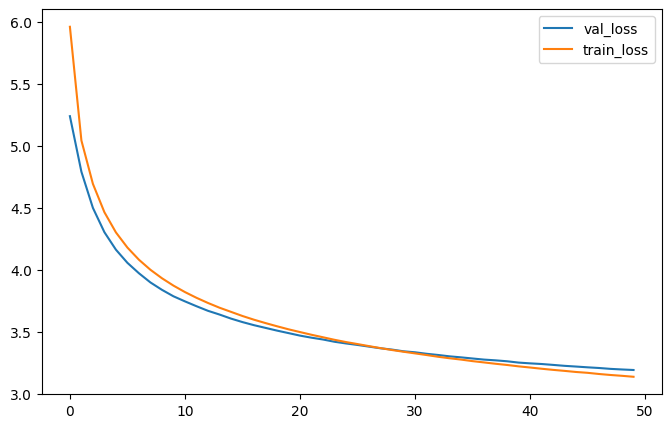

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 성적표 시각화 및 건강검진]
#
# 열심히 학습시킨 모델이 공부를 제대로 했는지 그래프로 확인하는 단계입니다.
# 숫자로만 보면 감이 잘 안 오기 때문에, 꺾은선 그래프를 그려서 한눈에 파악합니다.
#
# [무엇을 확인해야 하나요?]
# 1. Train Loss (연습문제 점수): 계속 떨어져야 정상입니다. (공부를 하고 있다는 뜻)
# 2. Val Loss (모의고사 점수): 같이 떨어져야 정상입니다. (응용력이 생겼다는 뜻)
#
# [주의할 패턴]
# - Train은 떨어지는데 Val이 갑자기 올라간다? -> "오버피팅(과적합)"
#   (문제집 답만 달달 외워서 실전 문제는 못 푸는 상태)
# - 둘 다 안 떨어진다? -> "언더피팅" (공부가 부족하거나 모델이 멍청함)
# ==============================================================================================

# 파이썬의 대표적인 시각화(그래프 그리기) 도구인 Matplotlib을 가져옵니다.
import matplotlib.pyplot as plt

# 1. X축 데이터 만들기 (시간의 흐름)
# train_loss 리스트에는 에폭(Epoch)마다 기록된 점수가 들어있습니다.
# 예: 50번 반복했다면 len(train_loss)는 50입니다.
# range(50) -> [0, 1, 2, ..., 49]까지의 숫자를 만들어 X축(Epoch)으로 씁니다.
eps = range(len(train_loss))

# 2. 도화지(Figure) 깔기
# 가로 8인치, 세로 5인치 크기의 빈 그래프 창을 만듭니다.
fig = plt.figure(figsize=(8,5))

# 3. 그래프 그리기 (선 긋기)
# plt.plot(X축, Y축, 라벨)

# (1) 검증 손실(Val Loss) 그리기
# 모의고사 성적 변화를 그립니다. 보통 이 선이 튀지 않고 잘 내려가는지가 제일 중요합니다.
plt.plot(eps, val_loss, label = 'val_loss')

# (2) 학습 손실(Train Loss) 그리기
# 평소 공부 성적 변화를 그립니다. 이건 웬만하면 계속 내려갑니다.
plt.plot(eps, train_loss, label = 'train_loss')

# 4. 범례(Legend) 표시하기
# 어떤 선이 'val_loss'이고 어떤 선이 'train_loss'인지 구별할 수 있게
# 그래프 구석에 이름표 박스를 띄웁니다.
plt.legend()

# (이 코드를 실행하면 그래프 이미지가 출력됩니다)

Train Loss와 Val Loss가 함께 감소하며 수렴하고 있어 과적합 없이 안정적으로 학습되고 있습니다.

텍스트 생성 예시를 보기위해 평가 데이터세트에서 입력 토큰을 bos 토큰 기준으로 잘라 질문 토큰만 입력하여 응답 토큰이 잘 생성되는지 확인합니다.

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 번역기 및 편집 가위 만들기]
#
# 모델은 0.1초 만에 수천 개의 숫자를 뱉어내지만, 사람은 그 숫자가 무슨 뜻인지 모릅니다.
# 또한 모델은 "질문+답변"을 통째로 학습했기 때문에, 테스트할 때는 질문(Prompt)과 답변(Response)을
# 깔끔하게 잘라내는 '가위'가 필요합니다.
#
# 1. decode_tokens (번역기):
#    - 숫자(Token ID)를 사람이 읽을 수 있는 글자(Text)로 바꿉니다.
#    - 그림 설명처럼 [EOS] 뒤의 내용이나, 빈칸 채우기용 [PAD]는 삭제합니다.
#
# 2. cut_bos (질문 오리기):
#    - 전체 문장에서 [BOS](질문과 답변의 경계선)를 찾습니다.
#    - 처음부터 [BOS]까지만 잘라내서 "이거 물어볼게" 하고 모델에게 던져줄 질문지를 만듭니다.
#
# 3. cut_generate (답변 오리기):
#    - 전체 문장에서 [BOS] 뒷부분만 잘라냅니다.
#    - 모델이 실제로 대답한 내용이 무엇인지 확인하기 위함입니다.
# ==============================================================================================

# [1. 숫자 해독기 (Decoder)]
# 예측 텍스트에서 eos토큰을 잘라 패딩을 제거
def decode_tokens(token_ids):
    """
    🎯 목적: 토큰 ID를 텍스트로 변환 (특수 토큰 제거)

    입력 예시: [ 234, 567, 890, 2,  0, 0 ]
                 └실제 단어┘ ↑ └패딩┘
                               EOS

    출력: "안녕하세요" (텍스트만)
    """
    # 1. 문장 종료 알림이(EOS) 토큰의 번호(ID)를 가져옵니다.
    #    이게 나오면 "아, 말 다 했구나" 하고 뒤는 무시해야 합니다.
    eos_token_id = sp.eos_id()

    # 2. 유효한 토큰들만 골라 담을 바구니를 준비합니다.
    tokens = []

    # 3. 숫자 리스트를 하나씩 꺼내서 검사합니다.
    for tid in token_ids:
        # [검사 1] 문장이 끝났나?
        # 만약 현재 숫자가 EOS(종료) 토큰이라면, 뒤에 뭐가 있든 멈춥니다. (Break)
        if eos_token_id is not None and tid == eos_token_id:
            break

        # [검사 2] 빈칸(Padding)인가?
        # 0번은 길이 맞추기용 허수아비이므로 해석하지 않고 건너뜁니다. (Continue)
        if tid == 0:
            # pad_token이면 skip하거나 그대로 처리
            continue

        # [통과] 실제 의미가 있는 단어라면 바구니에 담습니다.
        tokens.append(tid)

    # 4. SentencePiece의 기능을 이용해 숫자 바구니를 텍스트로 최종 변환합니다.
    #    예: [234, 567, 890] -> "안녕하세요"
    return sp.decode(tokens)


# [2. 질문지 오리기 (Prompt Slicer)]
# 입력 토큰을 만들기 위해 bos 토큰으로 슬라이스
def cut_bos(token_ids):
    """
    🎯 목적: 프롬프트 부분만 추출 (BOS 토큰까지)

    입력 예시: [1, 234, 567, 1, 890, 123]
               ↑           ↑ ← 두 번째 BOS
             첫 BOS

    출력: [1, 234, 567, 1] ← 두 번째 BOS까지만
    """
    # 1. 경계선 찾기
    #    token_ids[0]에서 [BOS] 토큰(문장 구분자)이 있는 위치(인덱스)를 모두 찾습니다.
    #    nonzero(): 0이 아닌(True인) 위치를 찾아줌.
    bos_positions = (token_ids[0] == sp.bos_id()).nonzero(as_tuple=True)[0]

    # 2. 첫 번째 경계선 위치 확보
    #    보통 질문과 답변 사이에 하나가 있으므로 첫 번째([0]) 위치를 가져옵니다.
    bos_idex = bos_positions[0].item()

    # 3. 가위질 (Slicing)
    #    처음(:)부터 ~ 경계선 위치(bos_idex) + 1까지 자릅니다.
    #    +1을 하는 이유는 파이썬 슬라이싱에서 마지막 숫자는 포함 안 되기 때문입니다. (BOS까지 포함하려고)
    prompt_inp = token_ids[:, :bos_idex+1]

    return prompt_inp


# [3. 답변 오리기 (Response Slicer)]
def cut_generate(token_ids):
    """
    🎯 목적: 생성된 부분만 추출 (BOS 토큰 이후)

    입력 예시: [1, 234, 567, 1, 890, 123]
               ↑           ↑ ← 두 번째 BOS
             첫 BOS       이후부터 추출

    출력: [890, 123] ← 두 번째 BOS 이후만
    """
    # 1. 경계선 찾기 (위와 동일)
    #    [BOS] 토큰이 어디 숨어있는지 찾습니다.
    bos_positions = (token_ids[0] == sp.bos_id()).nonzero(as_tuple=True)[0]

    # 2. 첫 번째 경계선 위치 확보
    bos_index = bos_positions[0].item()

    # 3. 가위질 (Slicing)
    #    경계선(bos_index) + 1 부터 ~ 끝(:)까지 자릅니다.
    #    즉, [BOS] 바로 뒷글자부터 문장 끝까지 가져옵니다. (순수 답변 내용만)
    prompt_inp = token_ids[:, bos_index+1:]

    return prompt_inp

In [ ]:
# ==============================================================================================
# [전체 흐름 요약: 최종 리허설 및 블라인드 테스트]
#
# 이제 학습된 모델이 실제로 얼마나 말을 잘하는지 확인하는 단계입니다.
# 시험 문제(Test Dataset) 하나를 꺼내서, "이거 풀어봐" 하고 시킵니다.
#
# 1. 시험 준비:
#    - 테스트용 데이터를 하나씩 꺼내는 로더를 만듭니다.
#    - 모델을 '평가 모드'로 바꾸고, 정답을 미리 보거나 수정(학습)하지 못하게 합니다.
#
# 2. 문제 출제 (Input Processing):
#    - 전체 데이터에서 '질문' 부분만 가위로 오려냅니다. (cut_bos)
#    - "자, 앞부분은 이거야. 뒷부분은 뭐라고 해야 할까?" 라고 모델에게 던져줍니다.
#
# 3. 답변 생성 (Generation):
#    - 모델이 한 글자씩 끙끙대며 답변을 만들어냅니다. (model.generate)
#
# 4. 채점 및 비교 (Comparison):
#    - 모델이 만든 답변을 한글로 번역합니다.
#    - 원래 정답지(Target)와 비교해서 얼마나 비슷한지 눈으로 확인합니다.
# ==============================================================================================

# [1. 시험장 세팅]
# 테스트 데이터셋에서 데이터를 하나씩(batch_size=1) 무작위로(shuffle=True) 꺼낼 준비를 합니다.
dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

all_preds=[] # (나중에 쓸 수도 있는) 예측 결과 모음 리스트
all_tars=[]  # (나중에 쓸 수도 있는) 실제 정답 모음 리스트

# 모델을 평가 모드(Evaluation Mode)로 전환!
# - 드롭아웃(Dropout) 끄기: 학습 땐 일부러 뇌세포를 껐지만, 시험 땐 풀가동해야 합니다.
model.eval()

# [2. 시험 시작]
# with torch.no_grad(): "메모 금지!"
# 시험 보는 중에는 공부(가중치 업데이트)를 하면 안 되므로, 미분값(Gradient) 계산을 멈춥니다.
# 메모리 절약과 속도 향상에 필수입니다.
with torch.no_grad():

    # 데이터로더에서 딱 하나의 샘플(질문-답변 쌍)을 꺼냅니다.
    for inpt, tar, mask in dataloader:

        # [데이터 준비]
        # 모델은 정수형(Long)만 먹을 수 있으므로 타입을 변환합니다.
        inp = inpt.long() # (1, 60) 크기의 입력 데이터
        tar = tar.long()  # (1, 60) 크기의 정답 데이터

        # [원본 확인]
        # 가공하기 전, 원래 이 데이터가 무슨 내용이었는지 확인해봅니다.
        # 예: "안녕 [BOS] 반가워 [EOS]"
        ori = decode_tokens(inp[0].tolist())
        print(f'original text: {ori}') # 원문 출력

        # [3. 문제와 정답지 분리]
        # 모델에게 줄 '질문'만 잘라냅니다. ([BOS] 토큰 앞부분)
        # 예: "안녕 [BOS]"
        cut_bos_inp = cut_bos(inp)

        # 나중에 비교할 '진짜 정답'만 잘라냅니다. ([BOS] 토큰 뒷부분)
        # 예: "반가워"
        cut_tar = cut_generate(tar)

        # 모델에게 들어갈 질문이 제대로 잘렸는지 텍스트로 확인합니다.
        input_text = decode_tokens(cut_bos_inp[0].tolist())
        print(f'input token:{cut_bos_inp}') # 숫자(토큰ID)로 확인
        print(f'input text:{input_text}')   # 글자(텍스트)로 확인

        # [4. 모델의 답변 생성 (핵심!)]
        # 잘라낸 질문(cut_bos_inp)을 주고, 뒤에 이어질 50글자(max_new_tokens)를 써보라고 시킵니다.
        # .to(device): 데이터를 GPU로 보내야 모델이 처리할 수 있습니다.
        pred = model.generate(cut_bos_inp.to(device), max_new_tokens=50)

        # [5. 결과 정리]
        # generate의 결과는 "질문 + 모델이만든답변" 형태입니다.
        # 여기서 우리가 필요한 건 뒤에 붙은 '모델이 만든 답변' 뿐이므로 다시 가위질합니다.
        pred = cut_generate(pred)

        # 숫자로 된 답변을 사람이 읽을 수 있는 한글로 번역(Decoding)합니다.
        # .cpu(): GPU에 있는 데이터를 출력하기 위해 CPU로 가져옵니다.
        pred_text = decode_tokens(pred[0].cpu().tolist())

        # [6. 결과 발표]
        print(f'predicted text:{pred_text}')  # 모델이 쓴 답

        # 실제 정답(Ground Truth)도 텍스트로 바꿔서 비교해봅니다.
        print(f'target text:{sp.decode(cut_tar[0].tolist())}')

        # 하나만 보고 반복문을 탈출합니다. (break)
        # 이거 안 하면 전체 테스트 데이터를 다 출력해서 화면이 꽉 찹니다.
        break

original text: 아내가 요즘 너무 바가지를 긁어 대 ⁇  어떤 식으로 하시는 걸까요 ⁇ 
input token:tensor([[  55,    5,   29,    9,  414,    5,   21,    7,    4, 3739,   45,  243,
            3,    1]])
input text:아내가 요즘 너무 바가지를 긁어 대 ⁇ 
predicted text:아내가 왜 그런 생각을 하셨나요 ⁇  좀 더 자세히 말씀해 주시겠어요 ⁇  수 있나요 ⁇  수 있나요 ⁇  수 있나요 ⁇  수 있나요 ⁇  수 있나
target text:어째서 못 나가게 하시는지 궁금해요 ⁇ 
